# Install packages

# Import

In [11]:
import os
import time
import torch
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import QM9, ZINC
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Model

In [12]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class Regress_graph(torch.nn.Module):
    def __init__(self, num_layer, num_feature, num_hidden):
        super(Regress_graph, self).__init__()
        self.num_layers = num_layer
        self.conv = torch.nn.ModuleList()
        self.conv.append(GCNConv(num_feature, num_hidden))
        for i in range(self.num_layers - 1):
            self.conv.append(GCNConv(num_hidden, num_hidden))
        self.lt1 = torch.nn.Linear(num_hidden, 1)

    def reset_parameters(self):
        for module in self.conv:
            module.reset_parameters()
        self.lt1.reset_parameters()

    def forward(self, gc):
        x, edge_index, batch = gc.x.float(), gc.edge_index, gc.batch
        for i in range(self.num_layers):
            x = self.conv[i](x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, training=self.training)
        x = global_mean_pool(x, batch)
        x = self.lt1(x)
        return x

# Utils

In [13]:
def train_test_val_split(dataset, shuffle=True):
    N = len(dataset)
    if shuffle:
        idx = torch.randperm(N)
    else:
        idx = torch.arange(N)
    train = []
    val = []
    test = []
    for i in range(N):
        if i < N//2:
            train.append(dataset[idx[i]])
        elif i < 3*N//4 and i >= N//2:
            val.append(dataset[idx[i]])
        else:
            test.append(dataset[idx[i]])
    return train, test, val

In [14]:
def train_model(train_loader, model, loss_fn, optimizer):
  all_output_train = torch.tensor([]).to(device)
  all_labels_train = torch.tensor([]).to(device)
  train_loss = 0
  model.train()
  optimizer.zero_grad()

  for graphs in train_loader:
    graphs = graphs.to(device)
    out = model(graphs)
    loss = loss_fn(out, graphs.y)
    #loss = loss_fn(out, graphs.y[:, 0].view(-1, 1))
    train_loss += loss.item()
    all_output_train = torch.cat((all_output_train, out))
    all_labels_train = torch.cat((all_labels_train, graphs.y))
    #all_labels_train = torch.cat((all_labels_train, graphs.y[:, 0].view(-1, 1)))
    loss.backward()
    optimizer.step()

  # train_acc = int(torch.sum(torch.argmax(all_output_train, dim=1) == all_labels_train).item()) / len(all_labels_train)
  train_loss = train_loss / len(train_loader)

  return train_loss / torch.std(all_labels_train).item()

def infer_model(loader, model, loss_fn):
  all_output = torch.tensor([]).to(device)
  all_labels = torch.tensor([]).to(device)
  all_loss = 0
  model.eval()

  for graphs in loader:
    graphs = graphs.to(device)
    out = model(graphs)
    loss = loss_fn(out, graphs.y)
    #loss = loss_fn(out, graphs.y[:, 0].view(-1, 1))
    all_loss += loss.item()
    all_output = torch.cat((all_output, out))
    all_labels = torch.cat((all_labels, graphs.y))
    #all_labels = torch.cat((all_labels, graphs.y[:, 0].view(-1, 1)))

  # acc = int(torch.sum(torch.argmax(all_output, dim=1) == all_labels).item()) / len(all_labels)
  all_loss = all_loss / len(loader)

  return all_loss  / torch.std(all_labels).item()

# Main

In [18]:
#dataset = QM9(root='./dataset')
dataset = ZINC(root='./dataset/ZINC', subset=True)
train_split, test_split, val_split = train_test_val_split(dataset, shuffle=True)
train_loader = DataLoader(train_split, batch_size=2, shuffle=True)
val_loader = DataLoader(val_split, batch_size=2, shuffle=False)
test_loader = DataLoader(test_split, batch_size=2, shuffle=False)

num_layer = 2
num_feature = dataset[0].x.shape[1]
num_hidden = 512

model = Regress_graph(num_layer, num_feature, num_hidden).to(device)
loss_fn = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

In [19]:
best_val_loss = float('inf')
best_test_loss = float('inf')
best_val_acc = 0
best_test_acc = 0
all_train_loss = []
all_val_loss = []
all_test_loss = []
for epoch in tqdm(range(100)):
  #Train model
  train_loss = train_model(train_loader, model, loss_fn, optimizer)
  all_train_loss.append(train_loss)
  #Validate Model
  val_loss = infer_model(val_loader, model, loss_fn)
  all_val_loss.append(val_loss)
  #Test Model
  test_loss = infer_model(test_loader, model, loss_fn)
  all_test_loss.append(test_loss)
  #save model
  if val_loss <= best_val_loss or epoch == 0:
    best_val_loss = val_loss
    best_test_loss = test_loss
    torch.save(model.state_dict(), 'model.pt')
    print("\n")
    print(f"train loss: {train_loss}")
    print(f"val loss: {val_loss}")
    print(f"test loss: {test_loss}")
    print("Best model saved")
    print("\n")

  if epoch == 0 or epoch%25 == 0:
    print("\n")
    print(f"train loss: {train_loss}")
    print(f"val loss: {val_loss}")
    print(f"test loss: {test_loss}")
    print("\n")


print("\n")
print(f"Best Val Loss: {best_val_loss}")
print(f"Best Test Loss: {best_test_loss}")
# print(f"Best Val Acc: {best_val_acc}")
# print(f"Best Test Acc: {best_test_acc}")

  0%|          | 0/100 [00:00<?, ?it/s]/home/royshubhajit/torch_pip/lib/python3.7/site-packages/torch/nn/modules/loss.py:101: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
  1%|          | 1/100 [00:49<1:21:03, 49.13s/it]



train loss: 16.34304774345307
val loss: 17.585159931421252
test loss: 16.55973626023043
Best model saved




train loss: 16.34304774345307
val loss: 17.585159931421252
test loss: 16.55973626023043




  6%|▌         | 6/100 [04:16<1:05:51, 42.04s/it]



train loss: 15.643762872836477
val loss: 9.469231098623036
test loss: 8.919456146673314
Best model saved




  7%|▋         | 7/100 [04:57<1:04:43, 41.76s/it]

...



train loss: 7.328527129666508
val loss: 0.9666363939805592
test loss: 0.9271486164487929
Best model saved




 76%|███████▌  | 76/100 [52:03<16:28, 41.20s/it]



train loss: 15.799345209889074
val loss: 2.9786925729685523
test loss: 2.807433432494734




 82%|████████▏ | 82/100 [56:11<12:20, 41.12s/it]


KeyboardInterrupt: 

# Plot loss

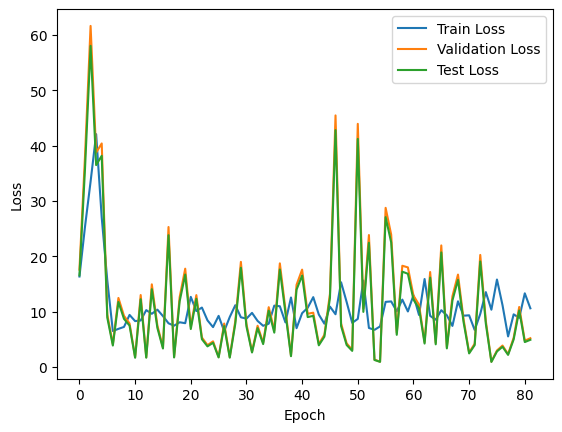

In [20]:
import matplotlib.pyplot as plt

plt.plot(all_train_loss, label='Train Loss')
plt.plot(all_val_loss, label='Validation Loss')
plt.plot(all_test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Baseline:

QM9 (property 0): 0.8435856775749379
ZINC subset: 0.6880267098736558